##### 실행 환경 설정

In [4]:
try:
    # Google Drive를 Colab에 마운트
    from google.colab import drive
    drive.mount('/google_drive')

    # 작업 경로 설정
    WORK_DIR = "/google_drive/Othercomputers/'내 컴퓨터'/sec08"
    print("\n[작업 폴더 목록]")
    %cd {WORK_DIR}
    !ls

    # 데이터셋 경로 설정
    DATASET_PATH = "/datasets/construction-ppe"
    import os
    if not os.path.exists(DATASET_PATH):
        !mkdir -p "/datasets/construction-ppe"
        # construction-ppe.zip 다운로드
        import urllib
        urllib.request.urlretrieve(
            "https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip",
            "/datasets/construction-ppe.zip"
        )
        # construction-ppe.zip 압축 해제
        !unzip -qn "/datasets/construction-ppe.zip" -d "/datasets/construction-ppe"
        # construction-ppe.zip 파일 삭제
        !rm "/datasets/construction-ppe.zip"
    print("\n[데이터셋 폴더 목록]")
    print(DATASET_PATH)
    !ls {DATASET_PATH}
    print(DATASET_PATH + "/images")
    !ls {DATASET_PATH}/images
    print(DATASET_PATH + "/labels")
    !ls {DATASET_PATH}/labels
    print()

    # data.yaml의 path를 절대 경로(앞에 / 붙임)로 변경
    import yaml
    yaml_path = "/datasets/construction-ppe/data.yaml"
    with open(yaml_path, 'r') as f:
        cfg = yaml.safe_load(f)
    cfg['path'] = '/datasets/construction-ppe'
    with open(yaml_path, 'w') as f:
        yaml.dump(cfg, f, allow_unicode=True, sort_keys=False)

    # 한글 폰트 설치
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm
    !apt-get -qq install fonts-nanum
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams['font.family'] = 'NanumGothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    # 데이터셋 경로 설정
    DATASET_PATH = "../datasets/construction-ppe"

    # 로컬 dataset 폴더 접근 확인
    import os
    print("\n[데이터셋 폴더 목록]")
    print(f"{DATASET_PATH}")
    for dir in os.listdir(DATASET_PATH):
        print(dir, end='  ')

    # 한글 폰트 설정
    import matplotlib.pyplot as plt
    plt.rcParams['font.family'] = 'Malgun Gothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False


[데이터셋 폴더 목록]
../datasets/construction-ppe
data.yaml  images  json  labels  LICENSE  yolo_to_labelme.py  

##### 임포트

In [ ]:
%%capture
!pip install -U ultralytics
from ultralytics import YOLO
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
import cv2
import glob
import random
import numpy as np
import time

# 노트북 셀에서 이미지 출력하기 위한 라이브러리(노트북에서 이미지 렌더링 속도 향상을 위해 사용)
from IPython.display import clear_output, Image as IPImage, display

##### Device 설정

In [4]:
# 디바이스 설정: GPU 사용 가능하면 cuda, 아니면 cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

사용 디바이스: cpu


##### 학습된 모델 로드

In [7]:
# 최적 가중치(best.pt) 로드
best_model = YOLO(f"runs/detect/03/weights/best.pt")

##### 추론하기

In [12]:
# 테스트셋에서 평가 이미지 파일 경로 리스트 얻기
test_images = glob.glob(f"{DATASET_PATH}/images/test/*.jpg")
print(test_images)

# 테스트셋에서 랜덤으로 이미지 파일 선택
test_image = random.choice(test_images)
print(f"선택된 이미지: {test_image}")

# 추론
pred_results = best_model.predict(          # best_model(...)와 동일
    test_image,
    # conf=0.25,                            # 신뢰도 임계값 (confidence threshold)
    save=True,                              # 결과 이미지 저장
    project="04", # 결과 저장 폴더
    name="predict",                         # 결과 저장 폴더 이름
    exist_ok=True                           # 결과 저장 폴더 덮어쓰기 여부
)

['../datasets/construction-ppe/images/test\\image1003.jpg', '../datasets/construction-ppe/images/test\\image1007.jpg', '../datasets/construction-ppe/images/test\\image1009.jpg', '../datasets/construction-ppe/images/test\\image1014.jpg', '../datasets/construction-ppe/images/test\\image1019.jpg', '../datasets/construction-ppe/images/test\\image1023.jpg', '../datasets/construction-ppe/images/test\\image1065.jpg', '../datasets/construction-ppe/images/test\\image1074.jpg', '../datasets/construction-ppe/images/test\\image1076.jpg', '../datasets/construction-ppe/images/test\\image1088.jpg', '../datasets/construction-ppe/images/test\\image1089.jpg', '../datasets/construction-ppe/images/test\\image110.jpg', '../datasets/construction-ppe/images/test\\image1111.jpg', '../datasets/construction-ppe/images/test\\image1114.jpg', '../datasets/construction-ppe/images/test\\image1120.jpg', '../datasets/construction-ppe/images/test\\image1125.jpg', '../datasets/construction-ppe/images/test\\image1132.jpg

##### 추론 시각화: 방법1 - Ultralytics 내장 시각화

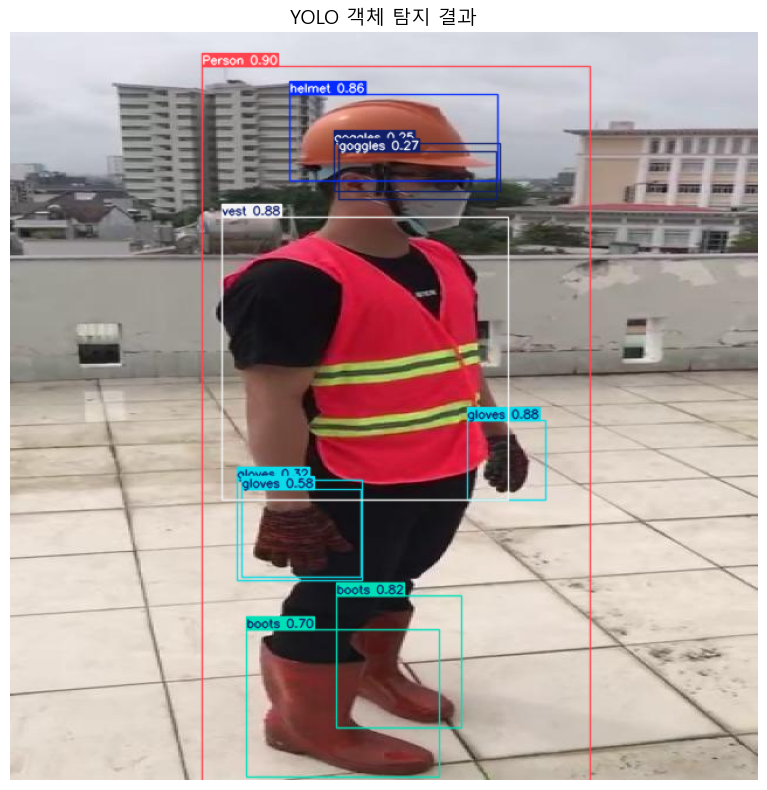

In [19]:
# 결과 이미지를 BGR numpy ndarray로 반환(내부적으로 OpenCV를 사용하기 때문)
annotated_bgr = pred_results[0].plot(
    line_width=1,    # 바운딩 박스 선 두께
    font_size=10,    # 레이블 폰트 크기 (내부적으로 cv2 scale에 매핑, 한계 있음)
    conf=True,       # 신뢰도 표시 여부
    labels=True,     # 레이블 표시 여부
)

# BGR 이미지를 RGB로 변환 (OpenCV는 BGR, Matplotlib는 RGB)
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

# Matplotlib으로 결과 이미지 표시
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(annotated_rgb)
ax.axis("off")
ax.set_title("YOLO 객체 탐지 결과", fontsize=14)
plt.tight_layout()
plt.show()

##### 추론 시각화: 방법2 - matplotlib으로 바운딩 박스 직접 그리기

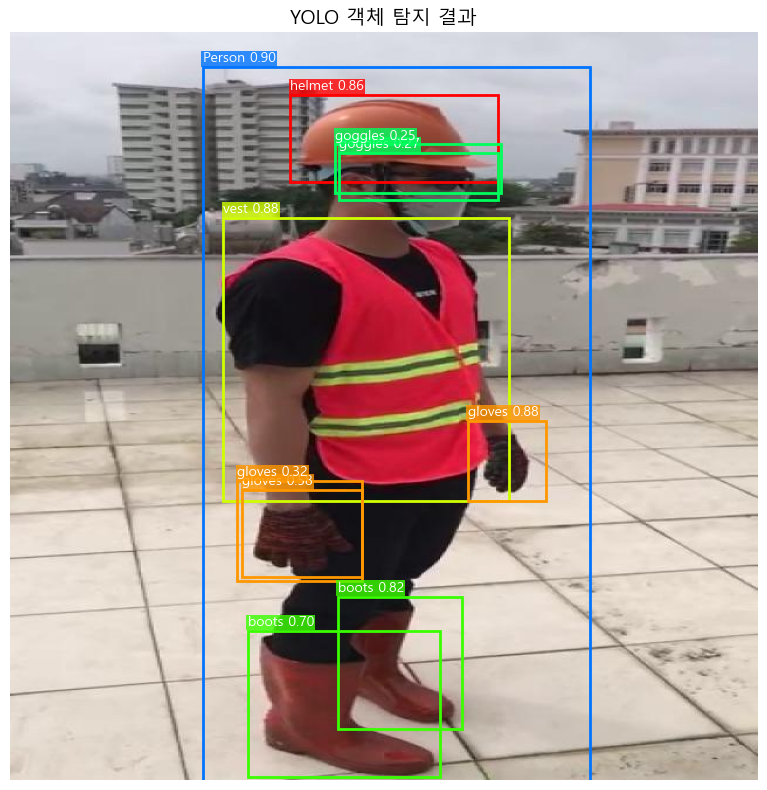

In [ ]:
# 원본 이미지 로드
img = mpimg.imread(Path(test_image).resolve())

# matplotlib으로 원본 이미지 표시
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.axis("off")
ax.set_title("YOLO 객체 탐지 결과", fontsize=14)

# 탐지된 객체 정보 (바운딩 박스 좌표, 클래스, 신뢰도) 추출
boxes = pred_results[0].boxes

# 클래스별 색상 자동 생성
# hsv 컬러 맵: 전체 클래스 수에 따라 다른 색상 생성
cmap = plt.colormaps.get_cmap("hsv").resampled(len(best_model.names))

# 탐지된 객체마다 바운딩 박스와 레이블 그리기
for box in boxes:
    # 좌상단/우하단 좌표 얻기
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    
    # 탐지된 클래스 레이블 얻기
    class_id = int(box.cls)
    
    # 클래스 이름 얻기
    class_name = best_model.names[class_id]
    
    # 신뢰도 얻기
    confidence = float(box.conf)
    
    # 클래스 레이블로 색상 선택
    color = cmap(class_id)

    # 바운딩 박스 그리기 (facecolor="none"으로 내부 투명하게)
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, 
        edgecolor=color, 
        facecolor="none"
    )
    # 바운딩 박스를 그래프에 추가
    ax.add_patch(rect)

    # 바운딩 박스 위에 클래스 이름과 신뢰도 레이블 그리기
    ax.text(
        x1, y1 - 4, # 바운딩 박스 바로 위에 레이블 위치
        f"{class_name} {confidence:.2f}", # 클래스 이름과 신뢰도 표시
        fontsize=10, color="white", # 글자 크기와 색상
        bbox={
            "facecolor":color,  # 레이블 배경 색상 (바운딩 박스와 동일)
            "alpha":0.8,        # 레이블 배경 투명도
            "pad":1,            # 레이블 배경과 글자 사이의 패딩
            "edgecolor":"none"  # 레이블 배경 테두리 없음
        }
    )

plt.tight_layout()
plt.show()

##### 업로드된 이미지를 추론해서 다운로드시키기

저장 완료: D:\Work\ai\05-ai-model-development\projects\ai-model-development-v2\sec08\runs\detect\04\predict\image63.jpg


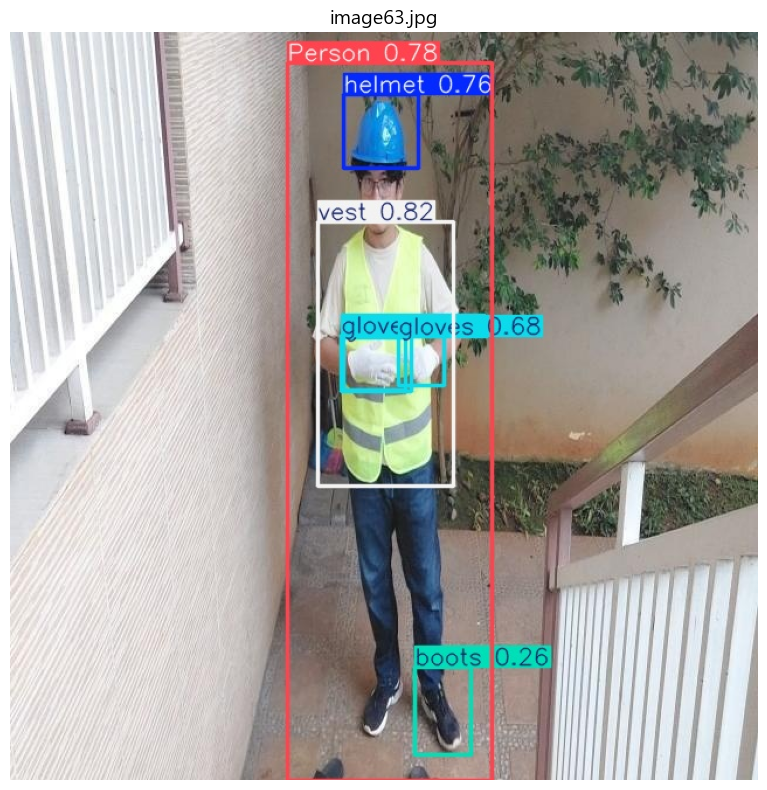

In [22]:
# 업로드된 이미지라고 가정
INPUT_PATH  = Path(f"{DATASET_PATH}/images/test/image63.jpg")

# 다운로드할 이미지라고 가정
OUTPUT_PATH = Path("runs/detect/04/predict/image63.jpg")

# 업로드된 파일의 바이트 배열 읽기
image_bytes = INPUT_PATH.read_bytes()

# 바이트 배열을 numpy ndarray로 변환
nparr = np.frombuffer(image_bytes, np.uint8)

# OpenCV로 디코딩하여 BGR 순서의 이미지 얻기
nparr = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

# 추론
result = best_model.predict(nparr, verbose=False)

# result[0].plot(): 추론 결과가 그려진 이미지 반환 (BGR 순서의 numpy ndarray)
# cv.imencode(): JPEG 형식으로 인코딩
# success: 인코딩 성공 여부
# jpg_img: JPEG 형식으로 인코딩된 이미지 (numpy ndarray)
success, jpg_img  = cv2.imencode(".jpg", result[0].plot())
result_bytes = jpg_img.tobytes()

# 추론 결과를 파일로 다운로드
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_bytes(result_bytes)
print(f"저장 완료: {OUTPUT_PATH.resolve()}")

# 추론 결과 이미지 보기
img = mpimg.imread(OUTPUT_PATH)
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.axis("off")
ax.set_title("image63.jpg", fontsize=14)
plt.tight_layout()
plt.show()

##### 실시간 비디오 영상 추론하고 시각화하기

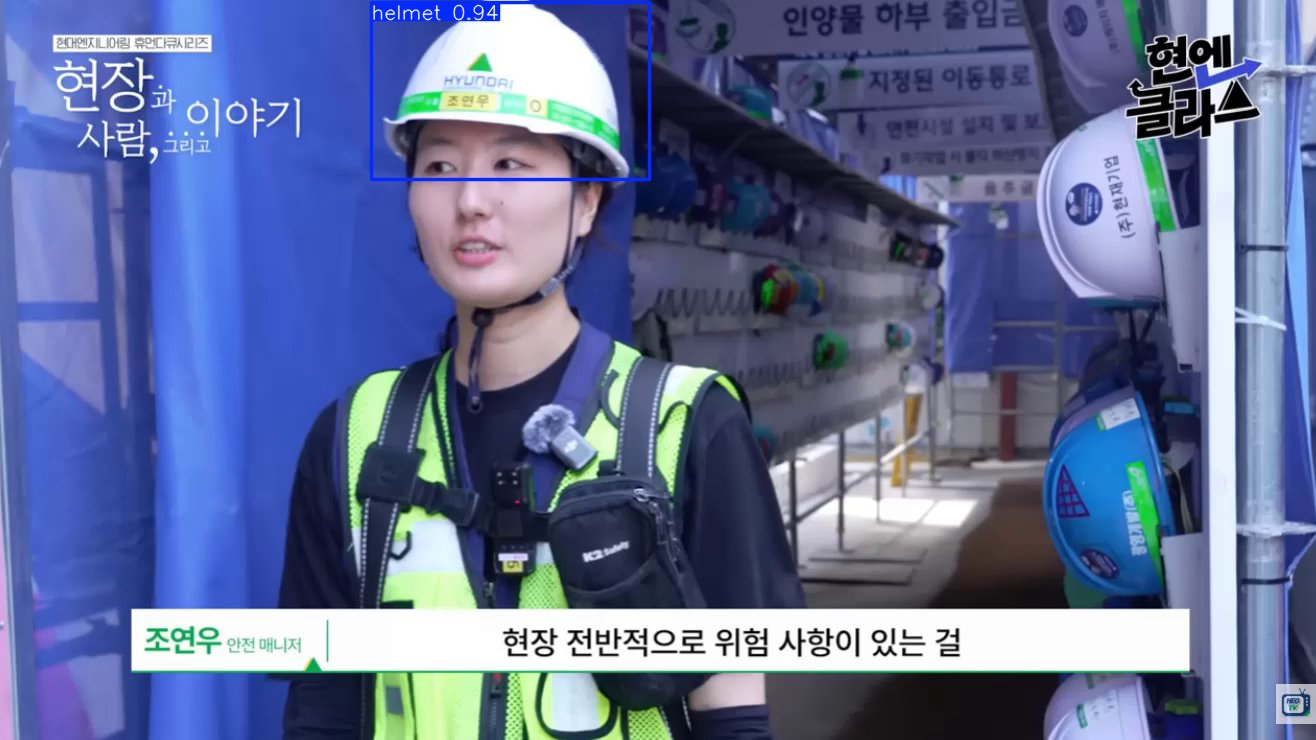

In [ ]:
# 실제로는 스트리밍으로 입력으로 프레임 얻기
VIDEO_PATH = Path("../datasets/videos/construction-ppe.mp4")
frame = cv2.VideoCapture(str(VIDEO_PATH))

# 프레임 속도(FPS) 계산
fps = frame.get(cv2.CAP_PROP_FPS) or 30
print(f"FPS: {fps:.2f}")
frame_interval = 1 / fps

try:
    # 프레임 단위로 영상 처리
    while frame.isOpened():
        # 시작 시간 기록
        t0 = time.time()

        # 프레임 읽기
        # success: 프레임 읽기 성공 여부, frame_bgr: 읽은 프레임 (BGR 순서의 numpy ndarray)
        success, frame_bgr = frame.read()
        if not success:
            break

        # 추론 → JPEG bytes
        pred_results = best_model.predict(frame_bgr, verbose=False)
        
        # 결과 이미지를 BGR numpy ndarray로 반환(내부적으로 OpenCV를 사용하기 때문)
        annotated_bgr = pred_results[0].plot(
            line_width=2,    # 바운딩 박스 선 두께
            font_size=12,    # 레이블 폰트 크기 (내부적으로 cv2 scale에 매핑, 한계 있음)
            conf=True,       # 신뢰도 표시 여부
            labels=True,     # 레이블 표시 여부
        )
        # success: 인코딩 성공 여부, jpg_img: JPEG 형식으로 인코딩된 이미지 (numpy ndarray)
        success, jpg_img = cv2.imencode(".jpg", annotated_bgr, [cv2.IMWRITE_JPEG_QUALITY, 85])

        # JPEG -> 바이트 배열로 변환
        jpg_bytes  = jpg_img.tobytes()

        # 이전 프레임 지우고 노트북에 프레임 보여주기
        # wait=False: 즉시 출력 지움. 다음 프레임이 나타날 때까지 빈 화면이 잠깐 보임 (깜빡임 발생)
        # wait=True: 이전 프레임이 사라지지 않고 다음 프레임이 나타날 때까지 유지 (깜빡임 없음)
        clear_output(wait=True)
        display(IPImage(data=jpg_bytes, width=800))

        # 추론·표시에 걸린 시간만큼 sleep 차감
        elapsed = time.time() - t0
        wait = frame_interval - elapsed
        if wait > 0:
            time.sleep(wait)
finally:
    # 프레임 자원 해제
    frame.release()
